In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn import metrics


In [2]:
data = pd.read_csv('data.csv')

In [3]:
data

,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,0,0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,1,1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,2,2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,3,3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,4,4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,926,1015,Asus,Vivobook 15X 2023 K3504VAB-NJ321WS Laptop,44990,69.323529,13th Gen ‎Intel Core i3 1315U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Integrated Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
889,927,1016,Asus,TUF A15 FA577RM-HQ032WS Laptop,110000,71.000000,6th Gen AMD Ryzen 7 6800H,"Octa Core, 16 Threads",16GB,DDR,1TB,SSD,6GB NVIDIA GeForce RTX 3060,15.6,2560.0,1440.0,Windows 11 OS,1
890,928,1017,Asus,ROG Zephyrus G14 2023 GA402XV-N2034WS Gaming L...,189990,89.000000,7th Gen AMD Ryzen 9 7940HS,"Octa Core, 16 Threads",32GB,DDR5,1TB,SSD,8GB NVIDIA GeForce RTX 4060,14.0,2560.0,1600.0,Windows 11 OS,1
891,929,1018,Asus,TUF Gaming F15 2023 FX507VU-LP083WS Gaming Laptop,129990,73.000000,13th Gen Intel Core i7 13700H,"14 Cores (6P + 8E), 20 Threads",16GB,DDR4,512GB,SSD,6GB NVIDIA GeForce RTX 4050,15.6,1920.0,1080.0,Windows 11 OS,1


In [4]:
data.head()

,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,0,0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,1,1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,2,2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,3,3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,4,4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1


In [5]:
data.tail()

,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
888,926,1015,Asus,Vivobook 15X 2023 K3504VAB-NJ321WS Laptop,44990,69.323529,13th Gen ‎Intel Core i3 1315U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Integrated Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
889,927,1016,Asus,TUF A15 FA577RM-HQ032WS Laptop,110000,71.000000,6th Gen AMD Ryzen 7 6800H,"Octa Core, 16 Threads",16GB,DDR,1TB,SSD,6GB NVIDIA GeForce RTX 3060,15.6,2560.0,1440.0,Windows 11 OS,1
890,928,1017,Asus,ROG Zephyrus G14 2023 GA402XV-N2034WS Gaming L...,189990,89.000000,7th Gen AMD Ryzen 9 7940HS,"Octa Core, 16 Threads",32GB,DDR5,1TB,SSD,8GB NVIDIA GeForce RTX 4060,14.0,2560.0,1600.0,Windows 11 OS,1
891,929,1018,Asus,TUF Gaming F15 2023 FX507VU-LP083WS Gaming Laptop,129990,73.000000,13th Gen Intel Core i7 13700H,"14 Cores (6P + 8E), 20 Threads",16GB,DDR4,512GB,SSD,6GB NVIDIA GeForce RTX 4050,15.6,1920.0,1080.0,Windows 11 OS,1
892,930,1019,Asus,TUF Gaming A15 2023 FA577XU-LP041WS Gaming Laptop,131990,84.000000,7th Gen AMD Ryzen 9 7940HS,"Octa Core, 16 Threads",16GB,DDR4,1TB,SSD,6GB NVIDIA GeForce RTX 4050,15.6,1920.0,1080.0,Windows 11 OS,1


In [6]:
data.shape

(893, 18)

In [7]:
print("Number of Rows", data.shape[0])
print("Number of Columns", data.shape[1])

Number of Rows 893
Number of Columns 18


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       893 non-null    int64  
 1   Unnamed: 0         893 non-null    int64  
 2   brand              893 non-null    str    
 3   name               893 non-null    str    
 4   price              893 non-null    int64  
 5   spec_rating        893 non-null    float64
 6   processor          893 non-null    str    
 7   CPU                893 non-null    str    
 8   Ram                893 non-null    str    
 9   Ram_type           893 non-null    str    
 10  ROM                893 non-null    str    
 11  ROM_type           893 non-null    str    
 12  GPU                893 non-null    str    
 13  display_size       893 non-null    float64
 14  resolution_width   893 non-null    float64
 15  resolution_height  893 non-null    float64
 16  OS                 893 non-null    st

In [9]:
data.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0           0
brand                0
name                 0
price                0
spec_rating          0
processor            0
CPU                  0
Ram                  0
Ram_type             0
ROM                  0
ROM_type             0
GPU                  0
display_size         0
resolution_width     0
resolution_height    0
OS                   0
warranty             0
dtype: int64

In [10]:
data = data.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1)
data.shape

(893, 16)

In [11]:
data.duplicated().any()

np.False_

In [12]:
data.duplicated().sum()

np.int64(0)

In [13]:
# Fill missing numerical values
data['spec_rating'] = data['spec_rating'].fillna(data['spec_rating'].mean())
data['display_size'] = data['display_size'].fillna(data['display_size'].mean())
data['resolution_width'] = data['resolution_width'].fillna(data['resolution_width'].mean())
data['resolution_height'] = data['resolution_height'].fillna(data['resolution_height'].mean())

# Fill missing categorical values
data['brand'] = data['brand'].fillna(data['brand'].mode()[0])
data['Ram'] = data['Ram'].fillna(data['Ram'].mode()[0])
data['Ram_type'] = data['Ram_type'].fillna(data['Ram_type'].mode()[0])
data['ROM'] = data['ROM'].fillna(data['ROM'].mode()[0])
data['ROM_type'] = data['ROM_type'].fillna(data['ROM_type'].mode()[0])
data['OS'] = data['OS'].fillna(data['OS'].mode()[0])

data.isnull().sum()

brand                0
name                 0
price                0
spec_rating          0
processor            0
CPU                  0
Ram                  0
Ram_type             0
ROM                  0
ROM_type             0
GPU                  0
display_size         0
resolution_width     0
resolution_height    0
OS                   0
warranty             0
dtype: int64

In [14]:
# Convert RAM from values such as 8GB to 8
data['Ram'] = data['Ram'].astype(str).str.replace('GB', '').astype(float)


In [15]:
# Convert ROM to GB
def convert_rom(x):
    x = str(x)
    if 'TB' in x:
        return float(x.replace('TB', '')) * 1024
    else:
        return float(x.replace('GB', ''))

data['ROM'] = data['ROM'].apply(convert_rom)

In [16]:
# Convert categorical columns into numbers
data['brand'] = data['brand'].astype('category').cat.codes
data['Ram_type'] = data['Ram_type'].astype('category').cat.codes
data['ROM_type'] = data['ROM_type'].astype('category').cat.codes
data['OS'] = data['OS'].astype('category').cat.codes

In [17]:
data.head()

,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,9,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8.0,2,512.0,1,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,12,1
1,9,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8.0,2,512.0,1,Intel UHD Graphics,15.6,1920.0,1080.0,12,1
2,1,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8.0,2,512.0,1,Intel Iris Xe Graphics,14.0,1920.0,1080.0,12,1
3,14,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16.0,8,512.0,1,Intel Integrated Iris Xe,14.0,2240.0,1400.0,12,1
4,2,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8.0,2,256.0,1,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,7,1


In [18]:
X = data[
    [
        'brand',
        'spec_rating',
        'Ram',
        'Ram_type',
        'ROM',
        'ROM_type',
        'display_size',
        'resolution_width',
        'resolution_height',
        'OS',
        'warranty'
    ]
]


In [19]:
y = data['price']

In [20]:
X.head()

,brand,spec_rating,Ram,Ram_type,ROM,ROM_type,display_size,resolution_width,resolution_height,OS,warranty
0,9,73.000000,8.0,2,512.0,1,15.6,1920.0,1080.0,12,1
1,9,60.000000,8.0,2,512.0,1,15.6,1920.0,1080.0,12,1
2,1,69.323529,8.0,2,512.0,1,14.0,1920.0,1080.0,12,1
3,14,66.000000,16.0,8,512.0,1,14.0,2240.0,1400.0,12,1
4,2,69.323529,8.0,2,256.0,1,13.3,2560.0,1600.0,7,1


In [21]:
y.head()

0    49900
1    39900
2    26990
3    59729
4    69990
Name: price, dtype: int64

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Rows:", X_train.shape[0])
print("Testing Rows:", X_test.shape[0])

Training Rows: 714
Testing Rows: 179


In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred1 = lr.predict(X_test)


In [24]:
svm = SVR()
svm.fit(X_train, y_train)
y_pred2 = svm.predict(X_test)

In [25]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred3 = rf.predict(X_test)

In [26]:
gr = GradientBoostingRegressor()
gr.fit(X_train, y_train)
y_pred4 = gr.predict(X_test)

In [27]:
df1 = pd.DataFrame({
    'Actual': y_test,
    'Linear Regression': y_pred1,
    'SVR': y_pred2,
    'Random Forest': y_pred3,
    'Gradient Boosting': y_pred4
})

df1.head(10)


,Actual,Linear Regression,SVR,Random Forest,Gradient Boosting
710,83090,82374.843666,63025.798758,84648.803333,93307.209762
440,57580,78093.821845,62988.403191,58216.190000,63178.552517
525,58990,92822.714631,63003.265841,71012.233333,64795.538624
721,142990,158554.230544,63039.311371,135634.836667,140771.103216
39,74990,79744.250005,62988.403974,78731.673333,77214.889305
290,56990,67213.322160,62988.400022,58555.048333,58521.970236
300,53990,31020.090702,62988.394010,76672.460000,48119.207925
333,57990,47670.006110,62988.396258,42651.918827,43743.771868
208,72490,94343.299887,63041.449213,73946.376667,78125.408319
136,23990,19979.451469,62963.888830,18331.460000,21395.591074


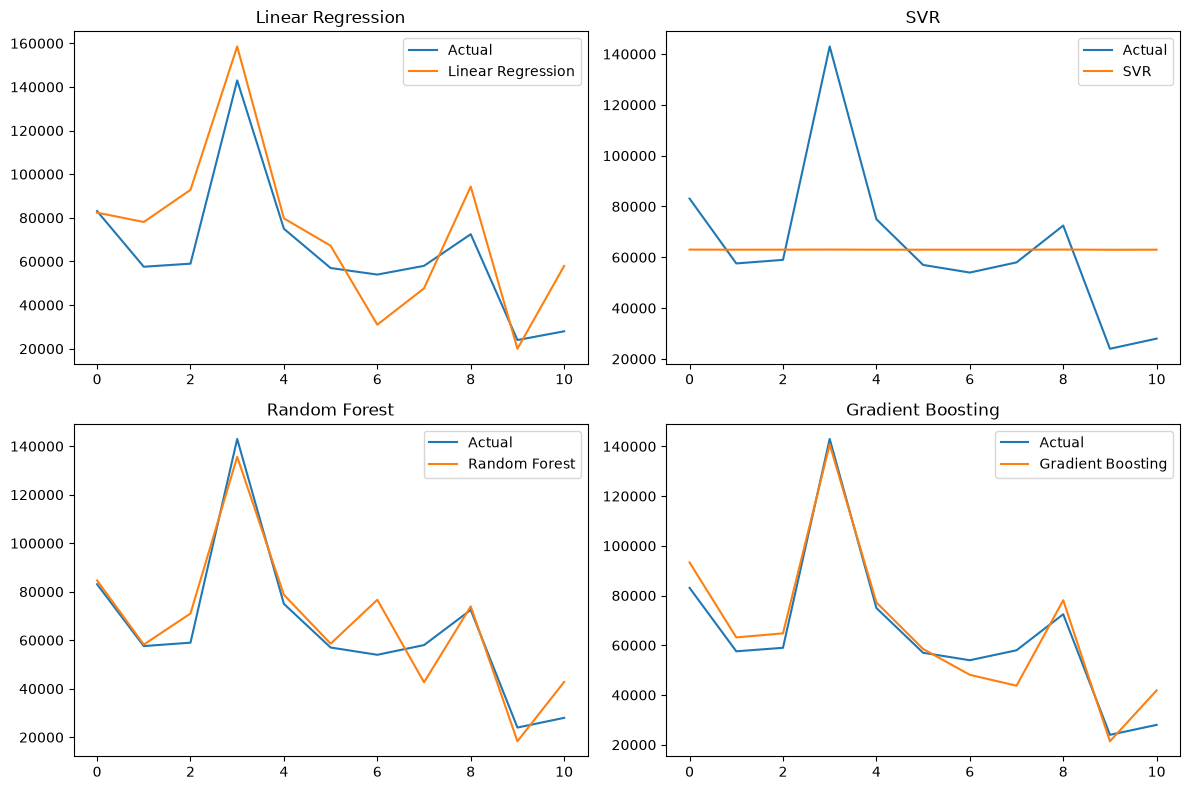

In [28]:
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.plot(y_test.iloc[0:11].values, label='Actual')
plt.plot(y_pred1[0:11], label='Linear Regression')
plt.title('Linear Regression')
plt.legend()

plt.subplot(222)
plt.plot(y_test.iloc[0:11].values, label='Actual')
plt.plot(y_pred2[0:11], label='SVR')
plt.title('SVR')
plt.legend()

plt.subplot(223)
plt.plot(y_test.iloc[0:11].values, label='Actual')
plt.plot(y_pred3[0:11], label='Random Forest')
plt.title('Random Forest')
plt.legend()

plt.subplot(224)
plt.plot(y_test.iloc[0:11].values, label='Actual')
plt.plot(y_pred4[0:11], label='Gradient Boosting')
plt.title('Gradient Boosting')
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
score1 = metrics.r2_score(y_test, y_pred1)
score2 = metrics.r2_score(y_test, y_pred2)
score3 = metrics.r2_score(y_test, y_pred3)
score4 = metrics.r2_score(y_test, y_pred4)

print("Linear Regression:", score1)
print("SVR:", score2)
print("Random Forest:", score3)
print("Gradient Boosting:", score4)

Linear Regression: 0.7489028291469852
SVR: -0.06048904858309845
Random Forest: 0.8551654348714035
Gradient Boosting: 0.8447441561807685


In [30]:
s1 = metrics.mean_absolute_error(y_test, y_pred1)
s2 = metrics.mean_absolute_error(y_test, y_pred2)
s3 = metrics.mean_absolute_error(y_test, y_pred3)
s4 = metrics.mean_absolute_error(y_test, y_pred4)

print("Linear Regression:", s1)
print("SVR:", s2)
print("Random Forest:", s3)
print("Gradient Boosting:", s4)

Linear Regression: 21088.701210217903
SVR: 34789.175973303245
Random Forest: 14091.08936049044
Gradient Boosting: 14633.485974797562


In [31]:
mse1 = metrics.mean_squared_error(y_test, y_pred1)
mse2 = metrics.mean_squared_error(y_test, y_pred2)
mse3 = metrics.mean_squared_error(y_test, y_pred3)
mse4 = metrics.mean_squared_error(y_test, y_pred4)

print("Linear Regression:", mse1)
print("SVR:", mse2)
print("Random Forest:", mse3)
print("Gradient Boosting:", mse4)

Linear Regression: 860420761.3699266
SVR: 3633919058.1341553
Random Forest: 496296578.6403761
Gradient Boosting: 532006596.85755944


In [32]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'SVR',
        'Random Forest',
        'Gradient Boosting'
    ],
    'R2 Score': [
        score1,
        score2,
        score3,
        score4
    ],
    'MAE': [
        s1,
        s2,
        s3,
        s4
    ],
    'MSE': [
        mse1,
        mse2,
        mse3,
        mse4
    ]
})

comparison

,Model,R2 Score,MAE,MSE
0,Linear Regression,0.748903,21088.701210,8.604208e+08
1,SVR,-0.060489,34789.175973,3.633919e+09
2,Random Forest,0.855165,14091.089360,4.962966e+08
3,Gradient Boosting,0.844744,14633.485975,5.320066e+08


In [33]:
print("Brand codes:")
print(data[['brand']].drop_duplicates().sort_values('brand'))

print("\nRAM Type codes:")
print(data[['Ram_type']].drop_duplicates().sort_values('Ram_type'))

print("\nROM Type codes:")
print(data[['ROM_type']].drop_duplicates().sort_values('ROM_type'))

print("\nOS codes:")
print(data[['OS']].drop_duplicates().sort_values('OS'))

Brand codes:
     brand
836      0
2        1
4        2
8        3
214      4
124      5
6        6
608      7
419      8
0        9
52      10
345     11
17      12
729     13
3       14
16      15
479     16
785     17
13      18
804     19
171     20
9       21
403     22
11      23
477     24
291     25
46      26
68      27
55      28
105     29

RAM Type codes:
     Ram_type
889         0
105         1
0           2
259         3
7           4
13          5
38          6
136         7
3           8
17          9
550        10
206        11

ROM Type codes:
    ROM_type
13         0
0          1

OS codes:
     OS
13    0
110   1
263   2
26    3
513   4
215   5
483   6
4     7
212   8
104   9
75   10
264  11
0    12
160  13


In [34]:
# Example new laptop.
# Replace the categorical codes below with the codes from the previous cell.

new_laptop = [[
    3,       # brand
    70,      # spec_rating
    16,      # RAM in GB
    2,       # RAM type
    512,     # ROM in GB
    1,       # ROM type
    15.6,    # display size
    1920,    # resolution width
    1080,    # resolution height
    5,       # OS
    1        # warranty
]]

new_pred = gr.predict(new_laptop)
print("Predicted Laptop Price:", new_pred)

Predicted Laptop Price: [74119.8955423]


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [35]:
import joblib

gr = GradientBoostingRegressor()
gr.fit(X, y)

joblib.dump(gr, 'laptop_price_model')
print("Model saved successfully.")

Model saved successfully.


In [36]:
model = joblib.load('laptop_price_model')

result = model.predict(new_laptop)

print("Predicted Laptop Price:", result)

Predicted Laptop Price: [66206.7528384]


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
